# SRNN interoperability experiment: paper reproduction with NeuroHLS

This notebook evaluates both official Braille recurrent SNN graphs: (1) zero reset with bias and 38 hidden neurons, and (2) subtractive reset without bias and 40 hidden neurons. Each generated **time-driven** NeuroHLS model processes the complete official test set of 140 sequences × 256 logical steps.

The models differ in weights, hidden width, bias, and reset semantics. Their accuracy difference must not be interpreted as an isolated reset ablation.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'neuro_hls').is_dir() else cwd.parent
sys.path.insert(0, str(repo_root / 'validation'))
import common as vc
import matplotlib.pyplot as plt

RUN_CSIM = vc.env_flag('NEUROHLS_RUN_CSIM', True)
FORCE = vc.env_flag('NEUROHLS_FORCE', False)
TIMEOUT_MINUTES = vc.env_int('NEUROHLS_TIMEOUT_MINUTES', 420)
USE_FLOAT = os.environ.get('NEUROHLS_ARITHMETIC', 'float').casefold() == 'float'
SAMPLES = vc.env_int('NEUROHLS_SRNN_SAMPLES', 140)
vc.ensure_directories()
print({'samples': SAMPLES, 'run_csim': RUN_CSIM, 'arithmetic': 'float' if USE_FLOAT else 'fixed-point'})

{'samples': 140, 'run_csim': True, 'arithmetic': 'float'}


## Generate and execute both recurrent models

A validation-only probe accumulates the first CUBA-LIF layer's spikes. Accuracy still comes from the normal seven-neuron output spike-count decoder.

In [2]:
runs = {}
accuracies = {}
hidden_rates = {}
for variant in ('zero_bias', 'subtract_no_bias'):
    project, sample_count = vc.generate_srnn_project(
        variant, samples=SAMPLES, use_float=USE_FLOAT, probe=True, force=FORCE
    )
    run_dir = vc.run_csim(project, timeout_minutes=TIMEOUT_MINUTES, execute=RUN_CSIM, force=FORCE)
    rates = vc.parse_srnn_rates(run_dir)
    rates.to_csv(vc.RESULTS_ROOT / f'srnn_{variant}_neurohls_hidden_rates.csv', index=False)
    vc.save_json(vc.RESULTS_ROOT / f'srnn_{variant}_csim_summary.json', vc.run_summary(run_dir))
    runs[variant] = run_dir
    accuracies[variant] = vc.csim_accuracy(run_dir)
    hidden_rates[variant] = rates
    print(f'{variant}: {accuracies[variant]:.2f}% ({run_dir})')

Total samples used: 140 of 140
Batch size: 1
Total batches: 140
Testbench was created.
zero_bias: 94.29% (/home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/runs/srnn_zero_bias_140_float_probe/20260819T021217Z-4ea96e390e52)
Total samples used: 140 of 140
Batch size: 1
Total batches: 140
Testbench was created.
subtract_no_bias: 93.57% (/home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/runs/srnn_subtract_no_bias_140_float_probe/20260819T021225Z-1b4a415e23c1)


## Accuracy comparison

Unlike the quick SCNN mode, NeuroHLS and the published libraries below use the same 140-sample Braille test set. Numerical and state-update conventions can still differ by backend.

experiment          variant      library  accuracy_percent  n_samples                     scope                                                                                                                              source  directly_comparable_full_test
      SRNN        zero_bias        Nengo         55.714286        140 official Braille test set                                                                                                                 NIR v1.0.4 artefact                           True
      SRNN        zero_bias        Norse         94.290000        140 official Braille test set                                                                                                                 NIR v1.0.4 artefact                           True
      SRNN        zero_bias     snnTorch         95.000000        140 official Braille test set                                                                                                                 NIR v1.0.4 arte

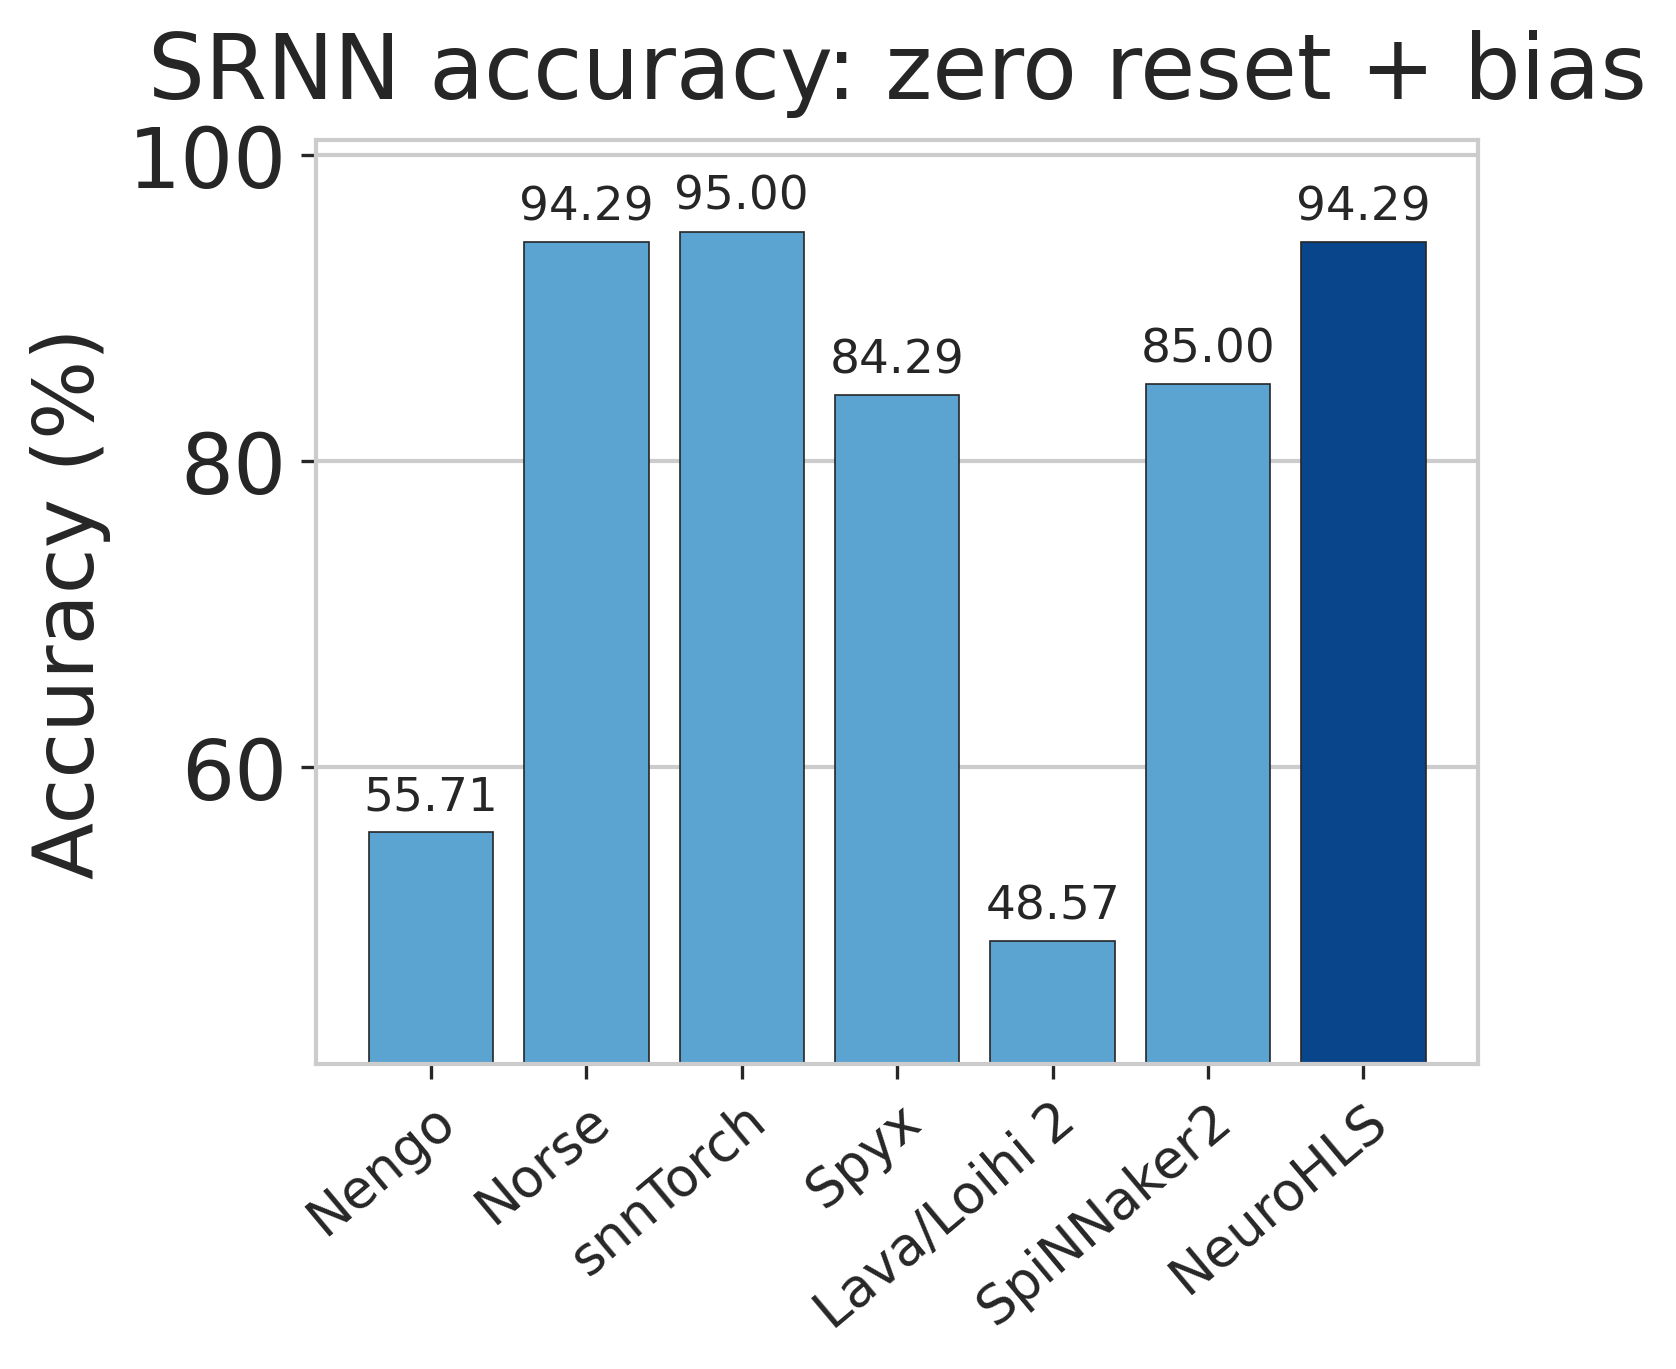

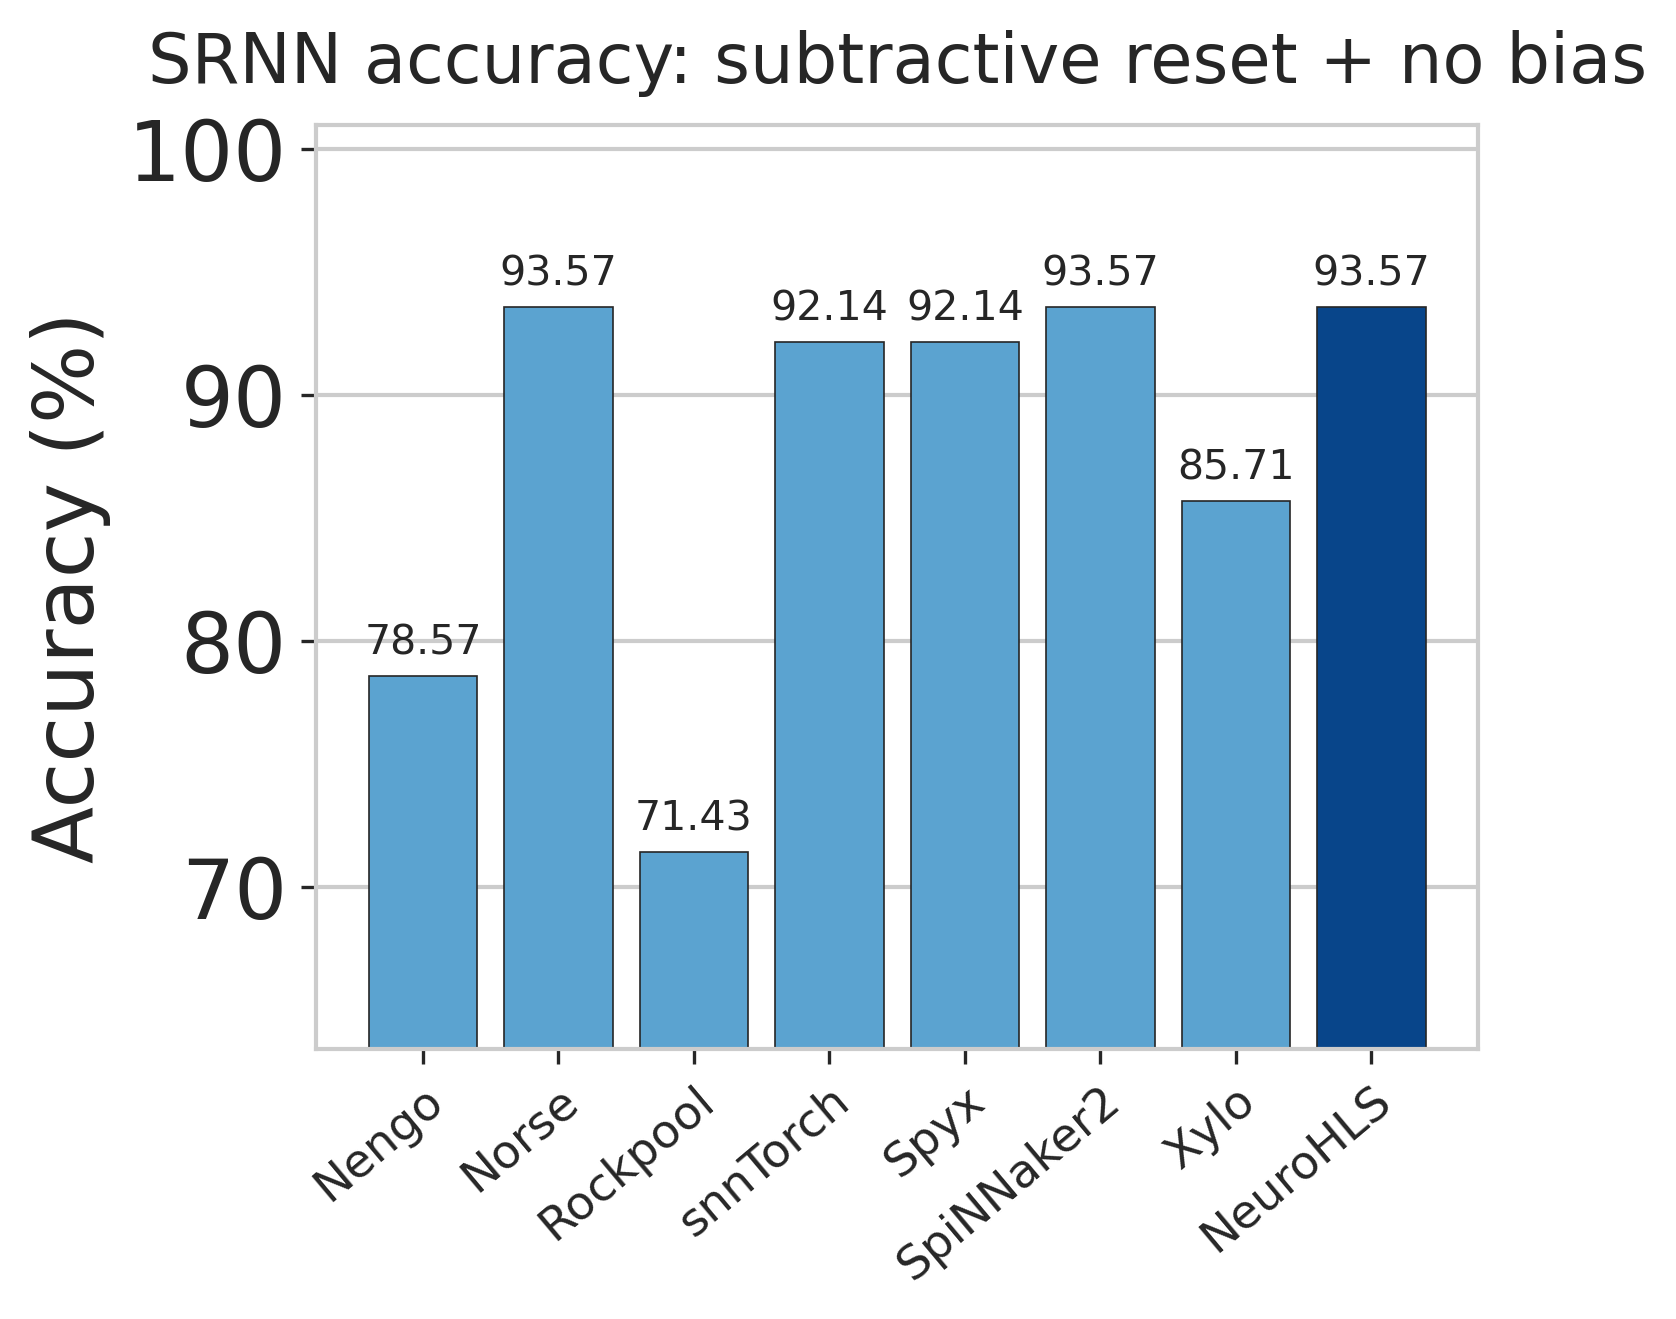

In [3]:
published = vc.accuracy_reference('SRNN').copy()
neurohls_rows = []
for variant, value in accuracies.items():
    neurohls_rows.append({
        'experiment': 'SRNN', 'variant': variant,
        'library': 'NeuroHLS', 'accuracy_percent': value,
        'n_samples': min(SAMPLES, 140),
        'scope': 'official Braille test set' if min(SAMPLES, 140) == 140 else 'prefix of official Braille test set',
        'source': str(runs[variant]),
    })
accuracy_table = pd.concat([published, pd.DataFrame(neurohls_rows)], ignore_index=True)
accuracy_table['directly_comparable_full_test'] = accuracy_table['n_samples'].eq(140)
accuracy_table.to_csv(vc.RESULTS_ROOT / 'srnn_accuracy_comparison.csv', index=False)
for variant in ('zero_bias', 'subtract_no_bias'):
    subset = accuracy_table[accuracy_table['variant'] == variant].reset_index(drop=True)
    vc.plot_accuracy(
        subset, f"SRNN accuracy: {vc.SRNN_VARIANTS[variant]['label']}",
        vc.RESULTS_ROOT / f'srnn_{variant}_accuracy.png',
    )
print(accuracy_table.to_string(index=False))

## Hidden-layer activity comparison

The official protocol uses only the first test sequence and compares the time-averaged first CUBA-LIF activity vector by cosine similarity. Each variant is compared only with implementations of that same graph.


zero_bias cosine similarity:
              Lava   Nengo   Norse  snnTorch  SpiNNaker2    Spyx  NeuroHLS
Lava        1.0000  0.7444  0.7740    0.8005      0.8506  0.7531    0.7740
Nengo       0.7444  1.0000  0.9411    0.9381      0.9632  0.9672    0.9411
Norse       0.7740  0.9411  1.0000    0.9986      0.9643  0.9932    1.0000
snnTorch    0.8005  0.9381  0.9986    1.0000      0.9668  0.9906    0.9986
SpiNNaker2  0.8506  0.9632  0.9643    0.9668      1.0000  0.9645    0.9643
Spyx        0.7531  0.9672  0.9932    0.9906      0.9645  1.0000    0.9932
NeuroHLS    0.7740  0.9411  1.0000    0.9986      0.9643  0.9932    1.0000

subtract_no_bias cosine similarity:
             Nengo   Norse  Rockpool  snnTorch  SpiNNaker2    Spyx    Xylo  NeuroHLS
Nengo       1.0000  0.9499    0.9224    0.9569      0.9556  0.9572  0.5831    0.9572
Norse       0.9499  1.0000    0.9846    0.9929      0.9862  0.9957  0.5806    0.9957
Rockpool    0.9224  0.9846    1.0000    0.9711      0.9486  0.9702  0.5207    

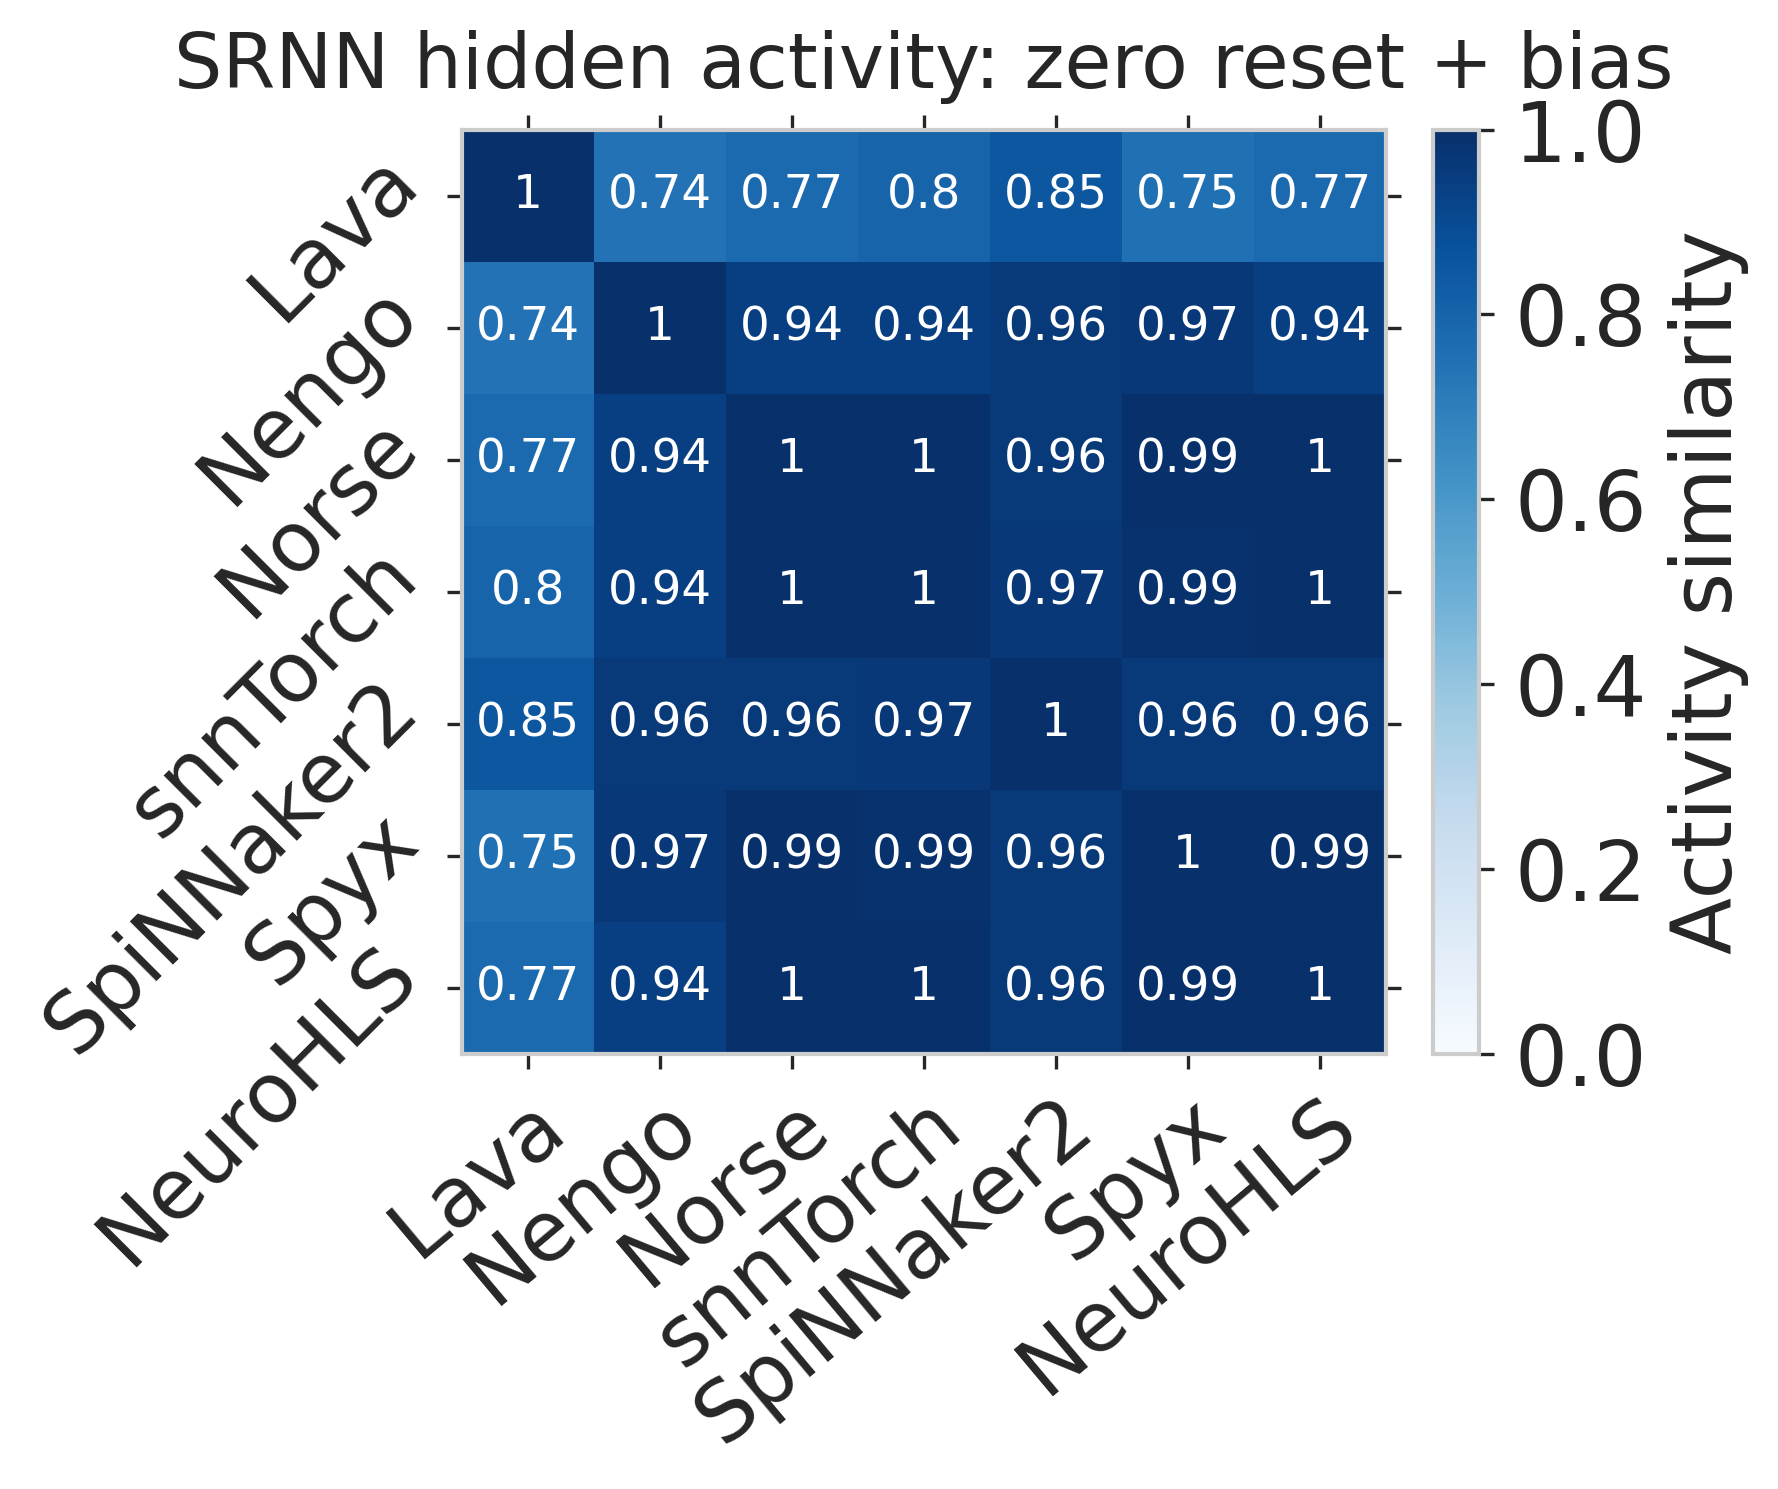

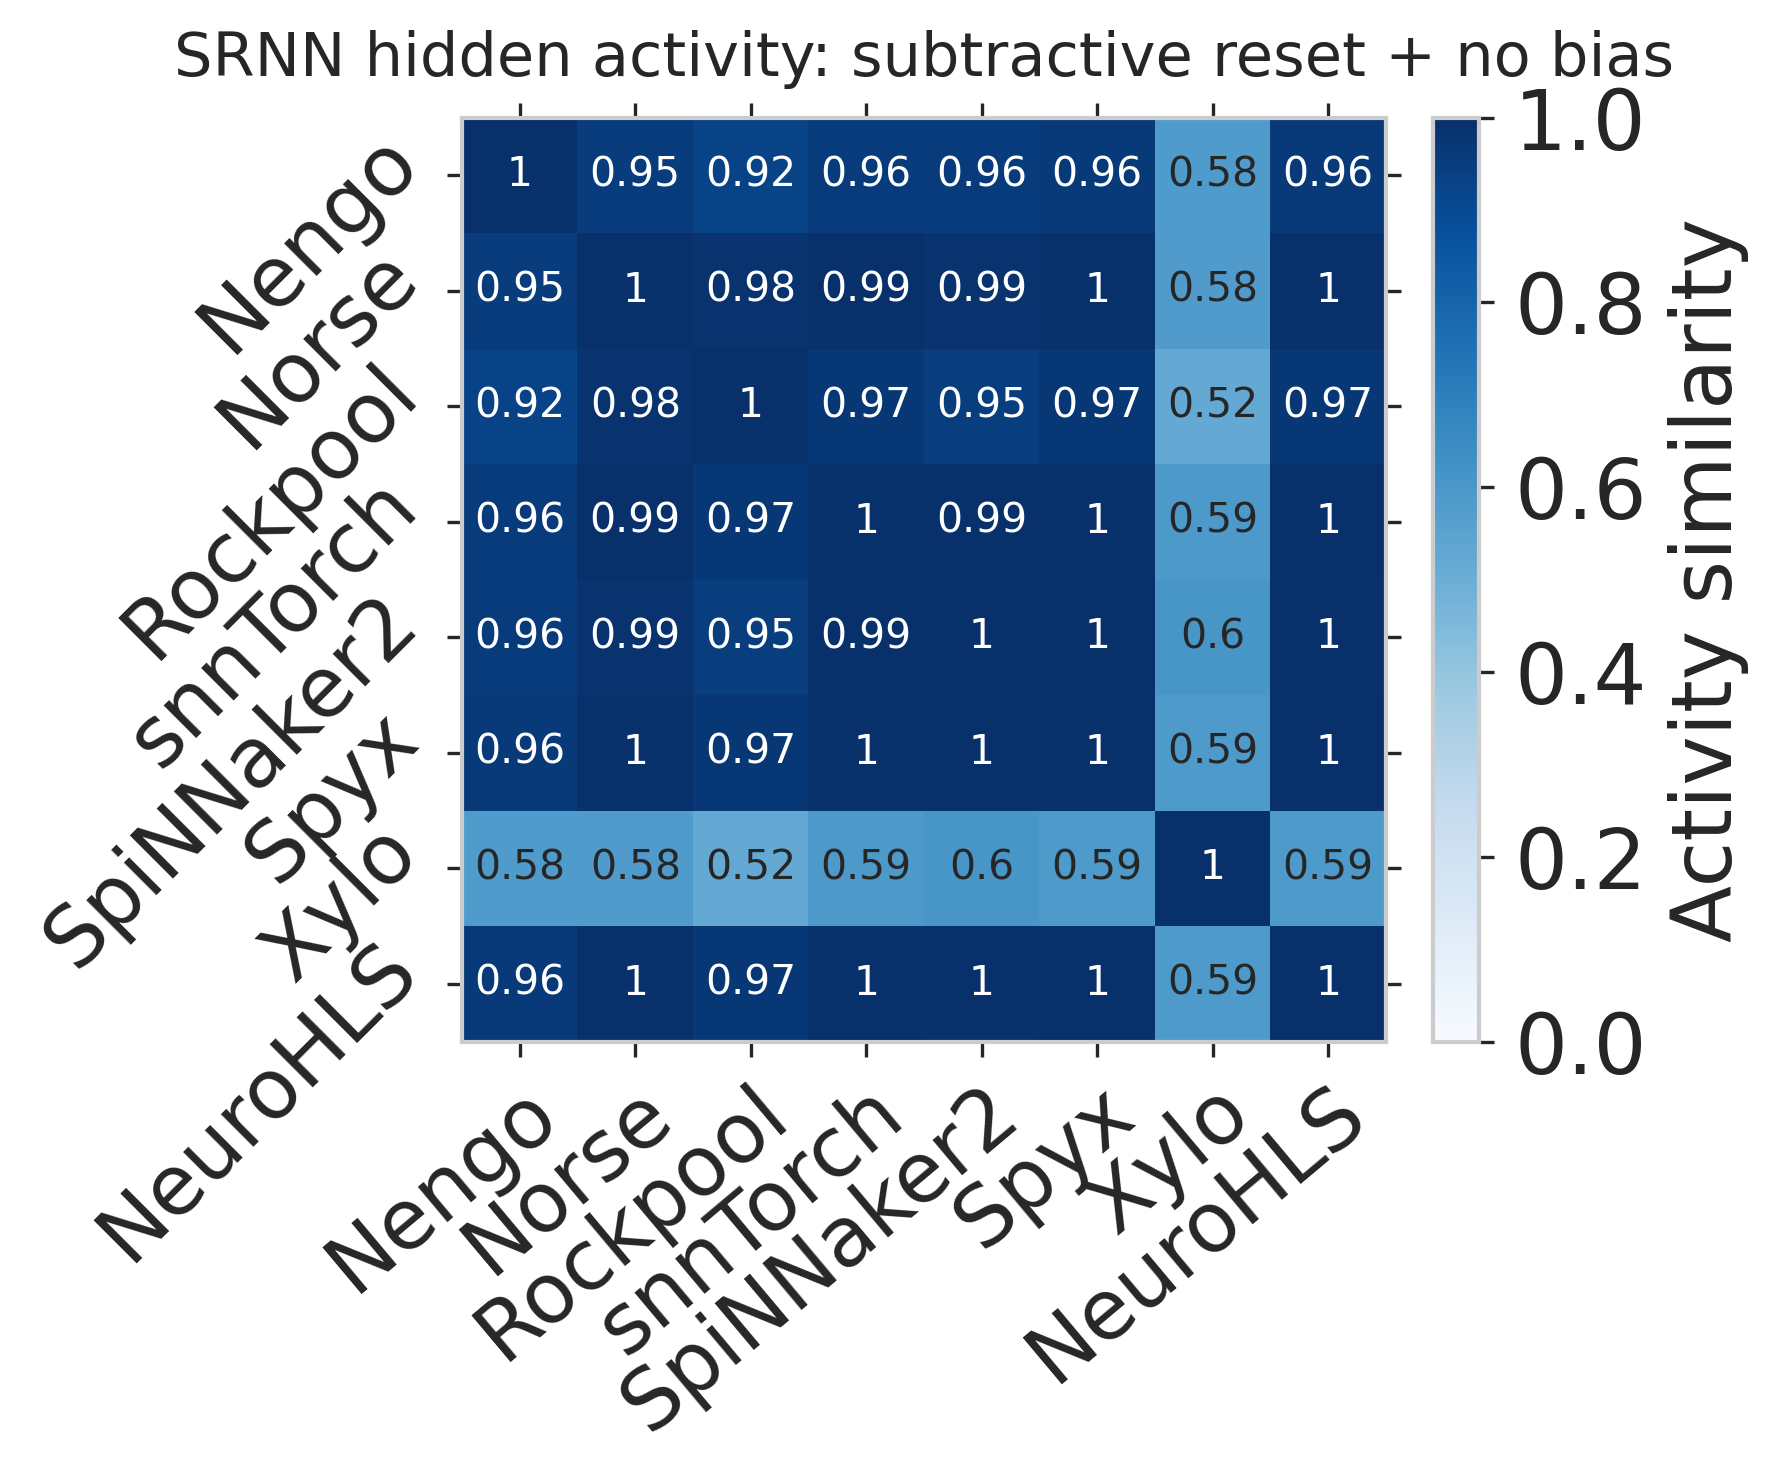

In [4]:
similarity_tables = {}
for variant in ('zero_bias', 'subtract_no_bias'):
    first_sample = (
        hidden_rates[variant][hidden_rates[variant]['sample'] == 0]
        .sort_values('neuron')['rate'].to_numpy()
    )
    rates = vc.load_srnn_reference_rates(variant)
    rates['NeuroHLS'] = first_sample
    labels, matrix = vc.cosine_matrix(rates)
    table = pd.DataFrame(matrix, index=labels, columns=labels)
    table.to_csv(vc.RESULTS_ROOT / f'srnn_{variant}_activity_similarity.csv')
    vc.plot_similarity(
        labels, matrix,
        f"SRNN hidden activity: {vc.SRNN_VARIANTS[variant]['label']}",
        vc.RESULTS_ROOT / f'srnn_{variant}_activity_similarity.png',
    )
    similarity_tables[variant] = table
    print(f'\n{variant} cosine similarity:')
    print(table.round(4).to_string())

/home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/results/srnn_provenance.json


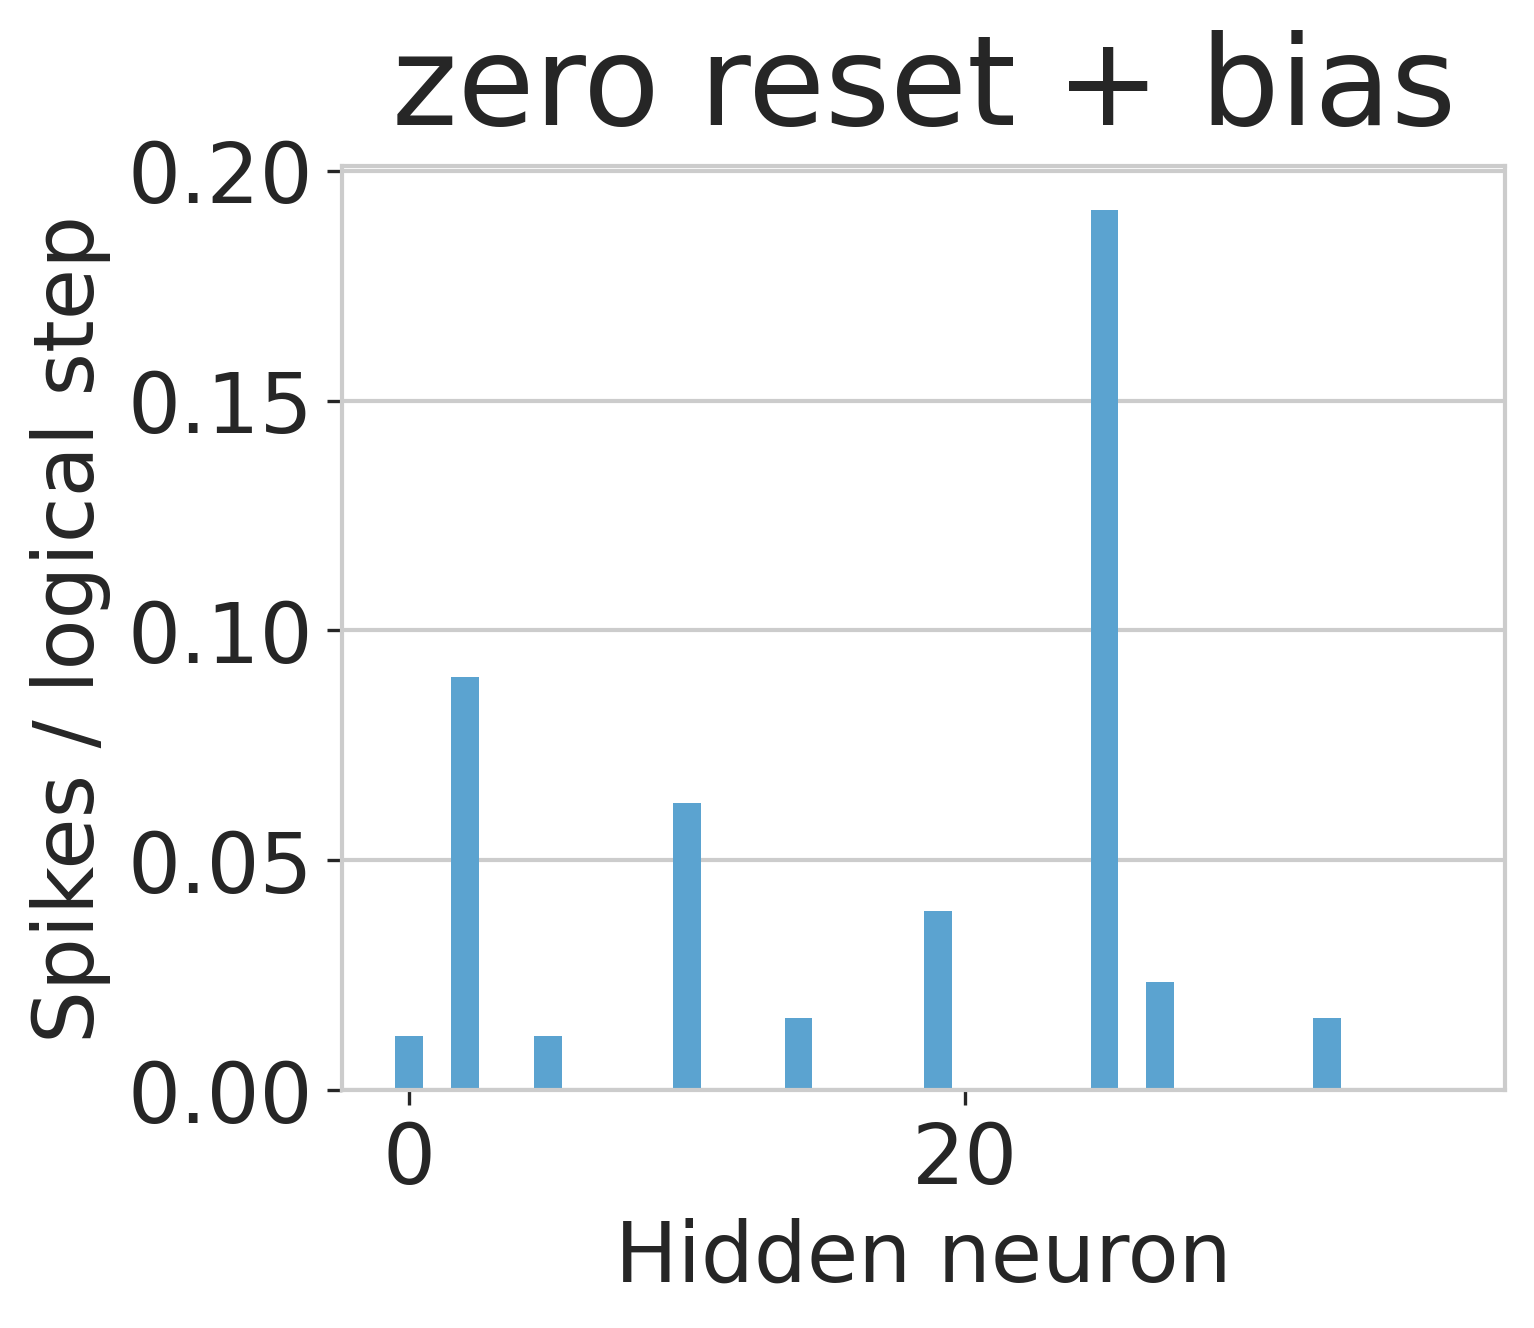

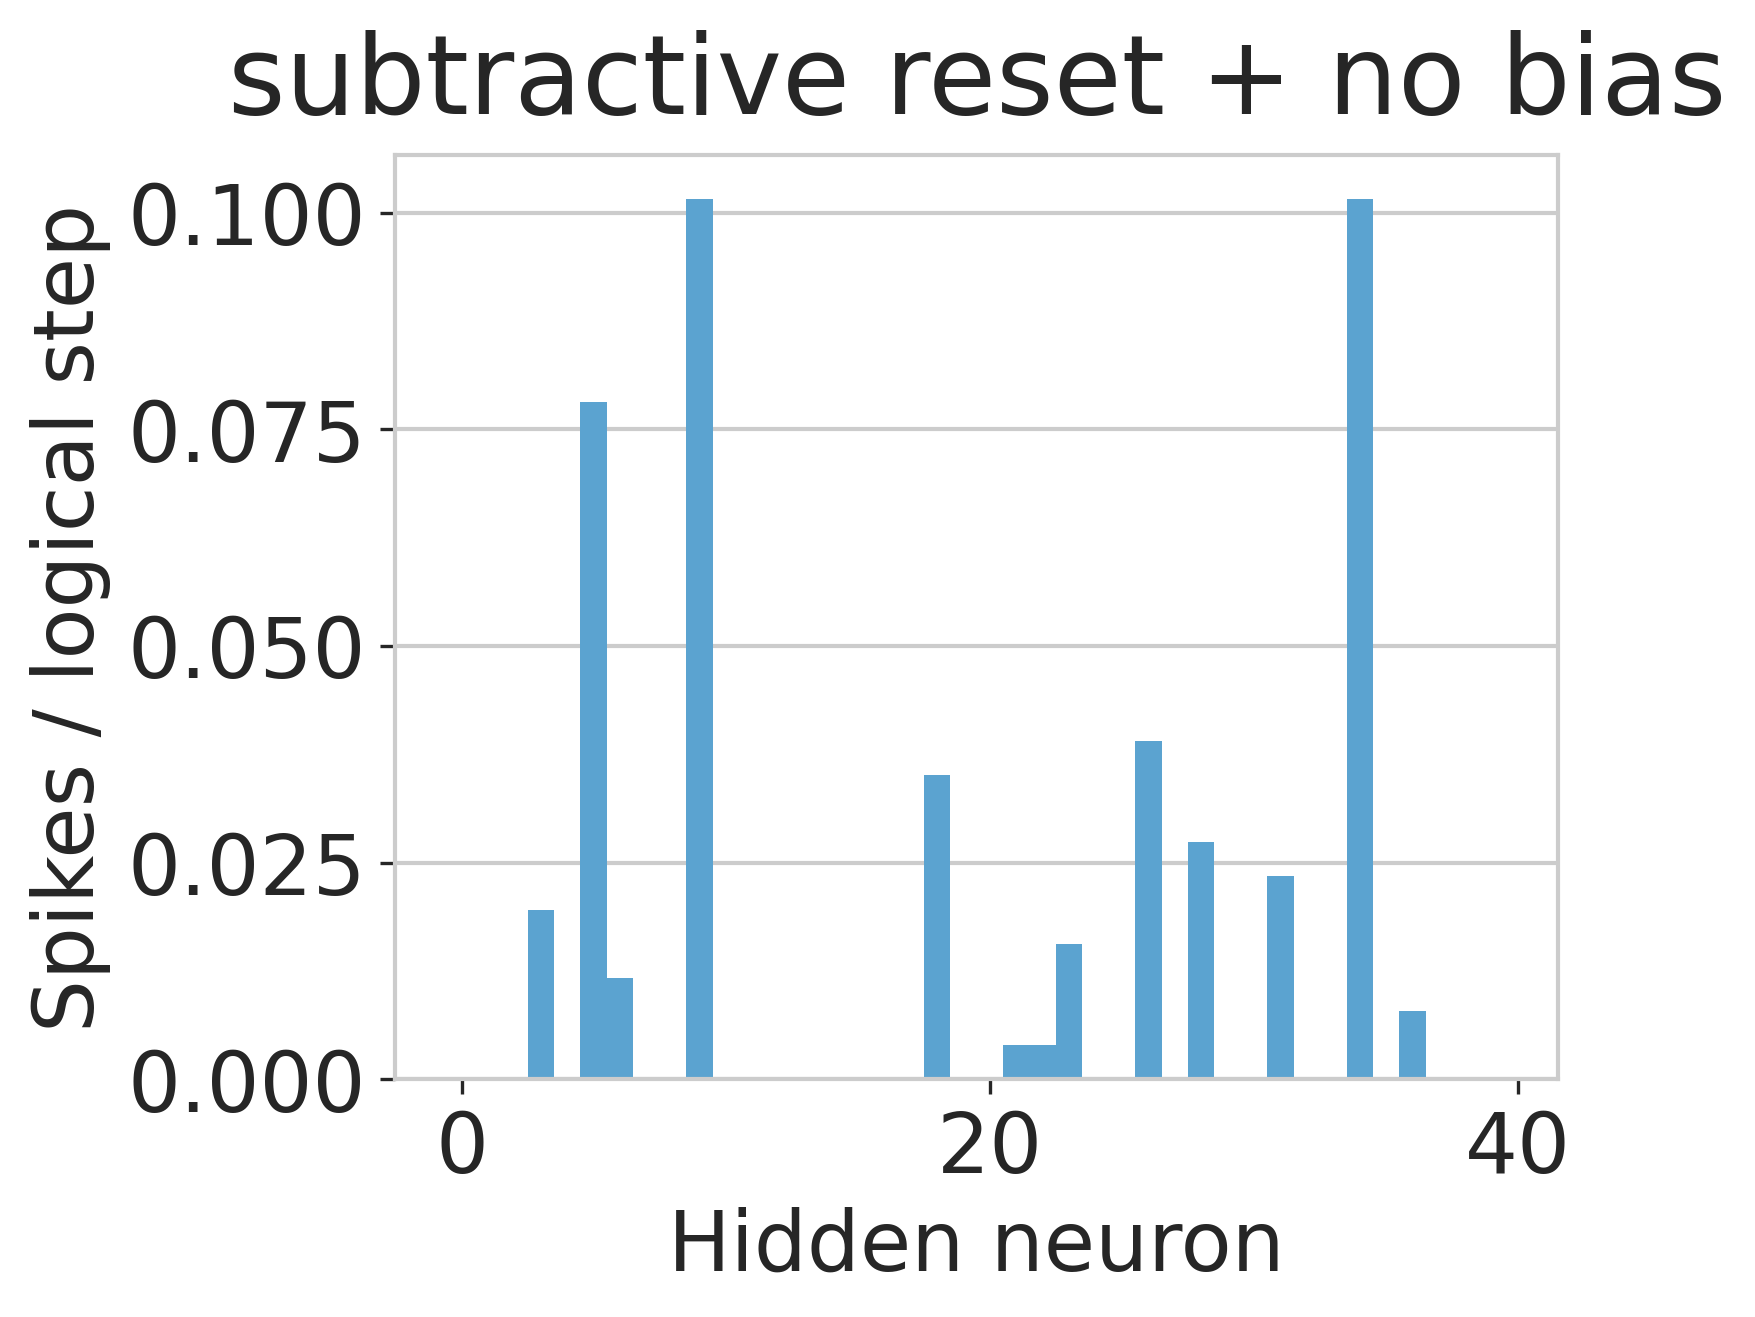

In [5]:
# One figure per variant on the paper's 5x4 inch / 300 dpi canvas, matching
# nir_paper/02_cnn/cnn_plots.ipynb.
for variant in ('zero_bias', 'subtract_no_bias'):
    first_sample = (hidden_rates[variant][hidden_rates[variant]['sample'] == 0]
                    .sort_values('neuron'))
    figure, axis = vc.paper_figure()
    axis.bar(
        first_sample['neuron'], first_sample['rate'],
        color=vc.paper_palette(len(first_sample)), width=1.0,
    )
    axis.grid(True, axis='y')
    axis.grid(False, axis='x')
    axis.set_xlabel('Hidden neuron')
    axis.set_ylabel('Spikes / logical step')
    vc.paper_title(figure, axis, vc.SRNN_VARIANTS[variant]['label'])
    vc.save_paper_figure(
        figure, vc.RESULTS_ROOT / f'srnn_{variant}_neurohls_hidden_activity.png',
    )

input_paths = {'dataset': vc.NIR_EXAMPLES / 'rnn_test.pt'}
for variant, config in vc.SRNN_VARIANTS.items():
    input_paths[f'{variant}_nir'] = config['nir']
    input_paths[f'{variant}_metadata'] = config['metadata']
vc.save_json(
    vc.RESULTS_ROOT / 'srnn_provenance.json',
    vc.provenance(
        input_paths, backend='time-driven', parallelism_p=0.0,
        arithmetic='float' if USE_FLOAT else 'fixed-point',
        samples=min(SAMPLES, 140), steps=256,
        runs={key: str(value) for key, value in runs.items()},
        note='The two variants differ in reset, bias, hidden width, and weights.',
    ),
)
print(vc.RESULTS_ROOT / 'srnn_provenance.json')